# 🎯 Détecteur de Régime de Marché
Objectif : classifier le marché en 3 régimes sur BTC/USDT 1h
- **MEAN_REV** → Stat Arb actif
- **TRENDING** → Momentum actif
- **HIGH_VOL** → Tout désactivé

Indicateurs utilisés :
1. **Hurst Rolling** — mesure la mean-reversion
2. **ADX** — force de la tendance
3. **Volatilité Réalisée** — niveau de stress

In [4]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print('✅ Imports OK')

✅ Imports OK


## 1. Données BTC 1h — 1 an

In [5]:
def fetch_ohlcv(symbol='BTC/USDT', timeframe='1h', days=365):
    exchange = ccxt.binance({'enableRateLimit': True})
    since = int((datetime.now() - timedelta(days=days)).timestamp() * 1000)
    all_ohlcv = []
    print(f'📥 Téléchargement {symbol} {timeframe} ({days}j)...')
    while True:
        try:
            ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1000)
            if not ohlcv: break
            all_ohlcv.extend(ohlcv)
            since = ohlcv[-1][0] + 1
            if ohlcv[-1][0] >= int(datetime.now().timestamp() * 1000) - 3600*1000:
                break
        except Exception as e:
            print(f'⚠️ {e}')
            break
    df = pd.DataFrame(all_ohlcv, columns=['timestamp','open','high','low','close','volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df = df.set_index('timestamp')
    df = df[~df.index.duplicated(keep='first')]
    print(f'✅ {len(df)} bougies chargées ({df.index[0].date()} → {df.index[-1].date()})')
    return df

df = fetch_ohlcv('BTC/USDT', '1h', days=365)

📥 Téléchargement BTC/USDT 1h (365j)...
✅ 8760 bougies chargées (2025-07-03 → 2026-07-03)


## 2. Calcul des indicateurs de régime

In [6]:
# ── A. HURST ROLLING ──────────────────────────────────────────
# < 0.45 = mean-reversion forte
# 0.45-0.55 = aléatoire (random walk)
# > 0.55 = tendance

def hurst_window(series, max_lag=20):
    """Hurst sur une fenêtre — version rapide"""
    try:
        lags = range(2, max_lag)
        tau  = [np.std(np.subtract(series[lag:], series[:-lag])) for lag in lags]
        if any(t == 0 for t in tau): return np.nan
        poly = np.polyfit(np.log(lags), np.log(tau), 1)
        return poly[0]
    except:
        return np.nan

HURST_WINDOW = 100  # 100h glissantes
print(f'⚙️ Calcul Hurst rolling ({HURST_WINDOW}h)...')
df['hurst'] = df['close'].rolling(HURST_WINDOW).apply(
    lambda x: hurst_window(x), raw=True
)

# ── B. ADX (Average Directional Index) ────────────────────────
# < 20 = pas de tendance (marché latéral)
# 20-40 = tendance modérée
# > 40 = tendance forte

def compute_adx(df, period=14):
    high, low, close = df['high'], df['low'], df['close']
    # True Range
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low  - close.shift(1)).abs()
    tr  = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.ewm(span=period, adjust=False).mean()
    # Directional Movements
    up   = high - high.shift(1)
    down = low.shift(1) - low
    plus_dm  = np.where((up > down) & (up > 0), up, 0.0)
    minus_dm = np.where((down > up) & (down > 0), down, 0.0)
    plus_di  = 100 * pd.Series(plus_dm,  index=df.index).ewm(span=period, adjust=False).mean() / atr
    minus_di = 100 * pd.Series(minus_dm, index=df.index).ewm(span=period, adjust=False).mean() / atr
    dx  = (100 * (plus_di - minus_di).abs() / (plus_di + minus_di)).fillna(0)
    adx = dx.ewm(span=period, adjust=False).mean()
    return adx, plus_di, minus_di

print('⚙️ Calcul ADX...')
df['adx'], df['plus_di'], df['minus_di'] = compute_adx(df, period=14)

# ── C. VOLATILITÉ RÉALISÉE ROLLING ────────────────────────────
# Écart-type annualisé des rendements sur 24h
# < 0.5 = calme  |  0.5-1.0 = normal  |  > 1.0 = stress

print('⚙️ Calcul volatilité réalisée...')
df['returns'] = df['close'].pct_change()
df['realized_vol'] = df['returns'].rolling(24).std() * np.sqrt(24 * 365)  # Annualisée

df = df.dropna()
print(f'\n✅ Indicateurs calculés — {len(df)} bougies utilisables')
print(f'   Hurst moyen        : {df["hurst"].mean():.3f}')
print(f'   ADX moyen          : {df["adx"].mean():.1f}')
print(f'   Vol réalisée moy.  : {df["realized_vol"].mean():.2f}')

⚙️ Calcul Hurst rolling (100h)...
⚙️ Calcul ADX...
⚙️ Calcul volatilité réalisée...

✅ Indicateurs calculés — 8661 bougies utilisables
   Hurst moyen        : 0.402
   ADX moyen          : 35.2
   Vol réalisée moy.  : 0.39


## 3. Visualisation des indicateurs bruts

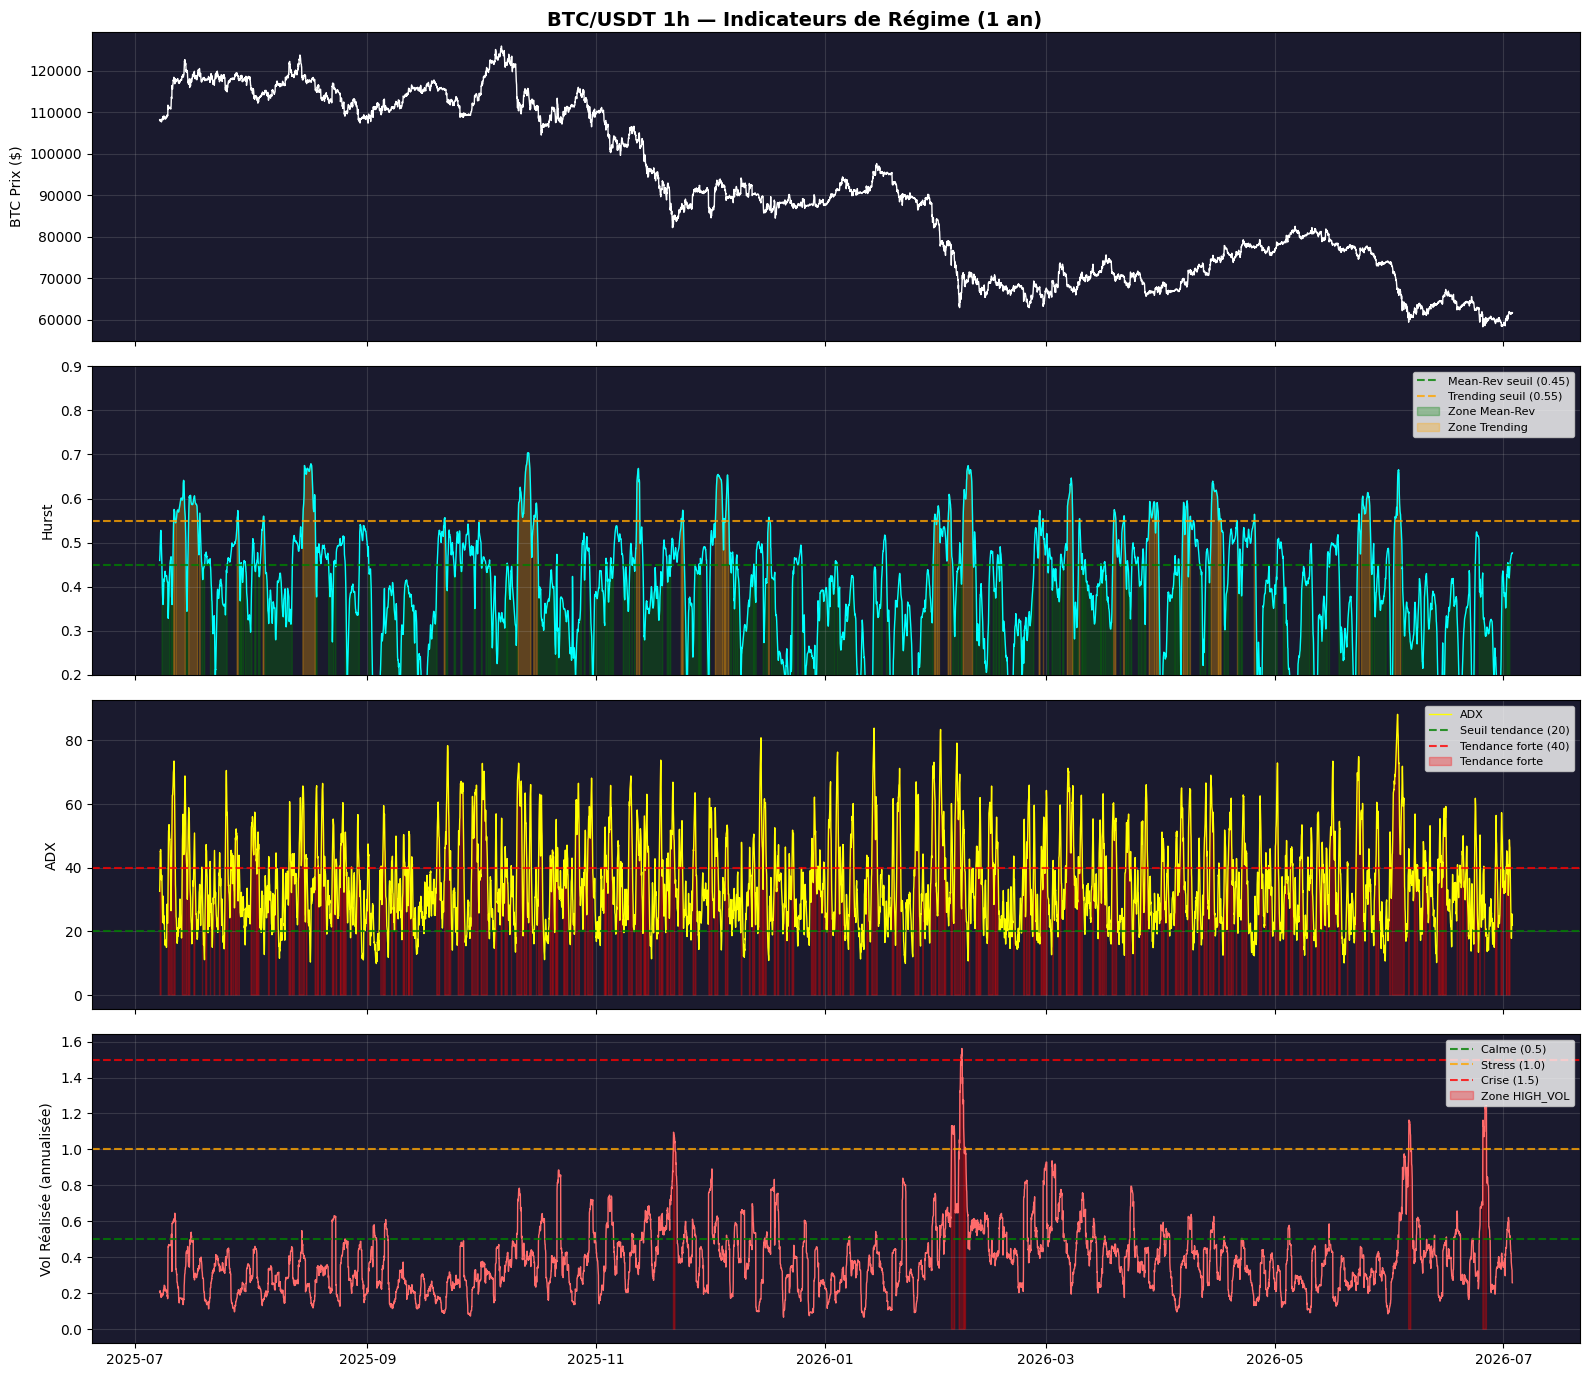

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('BTC/USDT 1h — Indicateurs de Régime (1 an)', fontsize=14, fontweight='bold')

# Prix
axes[0].plot(df.index, df['close'], color='white', linewidth=1)
axes[0].set_ylabel('BTC Prix ($)', fontsize=10)
axes[0].set_facecolor('#1a1a2e')
axes[0].grid(alpha=0.2)

# Hurst
axes[1].plot(df.index, df['hurst'], color='cyan', linewidth=1)
axes[1].axhline(0.45, color='green',  linestyle='--', alpha=0.8, label='Mean-Rev seuil (0.45)')
axes[1].axhline(0.55, color='orange', linestyle='--', alpha=0.8, label='Trending seuil (0.55)')
axes[1].fill_between(df.index, 0, df['hurst'],
    where=df['hurst'] < 0.45, alpha=0.3, color='green',  label='Zone Mean-Rev')
axes[1].fill_between(df.index, 0, df['hurst'],
    where=df['hurst'] > 0.55, alpha=0.3, color='orange', label='Zone Trending')
axes[1].set_ylabel('Hurst', fontsize=10)
axes[1].set_ylim(0.2, 0.9)
axes[1].legend(fontsize=8, loc='upper right')
axes[1].set_facecolor('#1a1a2e')
axes[1].grid(alpha=0.2)

# ADX
axes[2].plot(df.index, df['adx'], color='yellow', linewidth=1, label='ADX')
axes[2].axhline(20, color='green',  linestyle='--', alpha=0.8, label='Seuil tendance (20)')
axes[2].axhline(40, color='red',    linestyle='--', alpha=0.8, label='Tendance forte (40)')
axes[2].fill_between(df.index, 0, df['adx'],
    where=df['adx'] > 40, alpha=0.3, color='red', label='Tendance forte')
axes[2].set_ylabel('ADX', fontsize=10)
axes[2].legend(fontsize=8, loc='upper right')
axes[2].set_facecolor('#1a1a2e')
axes[2].grid(alpha=0.2)

# Volatilité réalisée
axes[3].plot(df.index, df['realized_vol'], color='#ff6b6b', linewidth=1)
axes[3].axhline(0.5, color='green',  linestyle='--', alpha=0.8, label='Calme (0.5)')
axes[3].axhline(1.0, color='orange', linestyle='--', alpha=0.8, label='Stress (1.0)')
axes[3].axhline(1.5, color='red',    linestyle='--', alpha=0.8, label='Crise (1.5)')
axes[3].fill_between(df.index, 0, df['realized_vol'],
    where=df['realized_vol'] > 1.0, alpha=0.3, color='red', label='Zone HIGH_VOL')
axes[3].set_ylabel('Vol Réalisée (annualisée)', fontsize=10)
axes[3].legend(fontsize=8, loc='upper right')
axes[3].set_facecolor('#1a1a2e')
axes[3].grid(alpha=0.2)

plt.style.use('dark_background')
plt.tight_layout()
plt.show()

## 4. Classification des régimes (règles simples)

In [8]:
# ── RÈGLES DE CLASSIFICATION ──────────────────────────────────
#
# HIGH_VOL  (priorité 1) : vol réalisée > 1.0  ← stress, tout off
# TRENDING  (priorité 2) : ADX > 25 ET Hurst > 0.52
# MEAN_REV  (priorité 3) : Hurst < 0.48 ET ADX < 30
# NEUTRAL   (défaut)     : aucune condition claire
#
# Ces seuils sont des points de départ — on les calibrera
# après avoir vu la distribution ci-dessous

VOL_THRESHOLD      = 0.60   # ~P85 vol réalisée  → ~15% HIGH_VOL
ADX_TREND          = 28     # légèrement sous P50 ADX
ADX_MEAN_REV       = 36     # ajusté pour réduire NEUTRAL
HURST_MEAN_REV_MAX = 0.43   # ajusté → ~28% MEAN_REV
HURST_TREND_MIN    = 0.47   # ~P70 Hurst → ~30% TRENDING

def classify_regime(row):
    if row['realized_vol'] > VOL_THRESHOLD:
        return 'HIGH_VOL'
    elif row['adx'] > ADX_TREND and row['hurst'] > HURST_TREND_MIN:
        return 'TRENDING'
    elif row['hurst'] < HURST_MEAN_REV_MAX and row['adx'] < ADX_MEAN_REV:
        return 'MEAN_REV'
    else:
        return 'NEUTRAL'

df['regime'] = df.apply(classify_regime, axis=1)

# Distribution
dist = df['regime'].value_counts()
print('📊 DISTRIBUTION DES RÉGIMES')
print('='*40)
for regime, count in dist.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {regime:<12} : {count:>5} bougies ({pct:>5.1f}%) {bar}')

print(f'\n  Total : {len(df)} bougies')

📊 DISTRIBUTION DES RÉGIMES
  NEUTRAL      :  3249 bougies ( 37.5%) ██████████████████
  MEAN_REV     :  2828 bougies ( 32.7%) ████████████████
  TRENDING     :  1579 bougies ( 18.2%) █████████
  HIGH_VOL     :  1005 bougies ( 11.6%) █████

  Total : 8661 bougies


## 5. Visualisation des régimes sur le prix

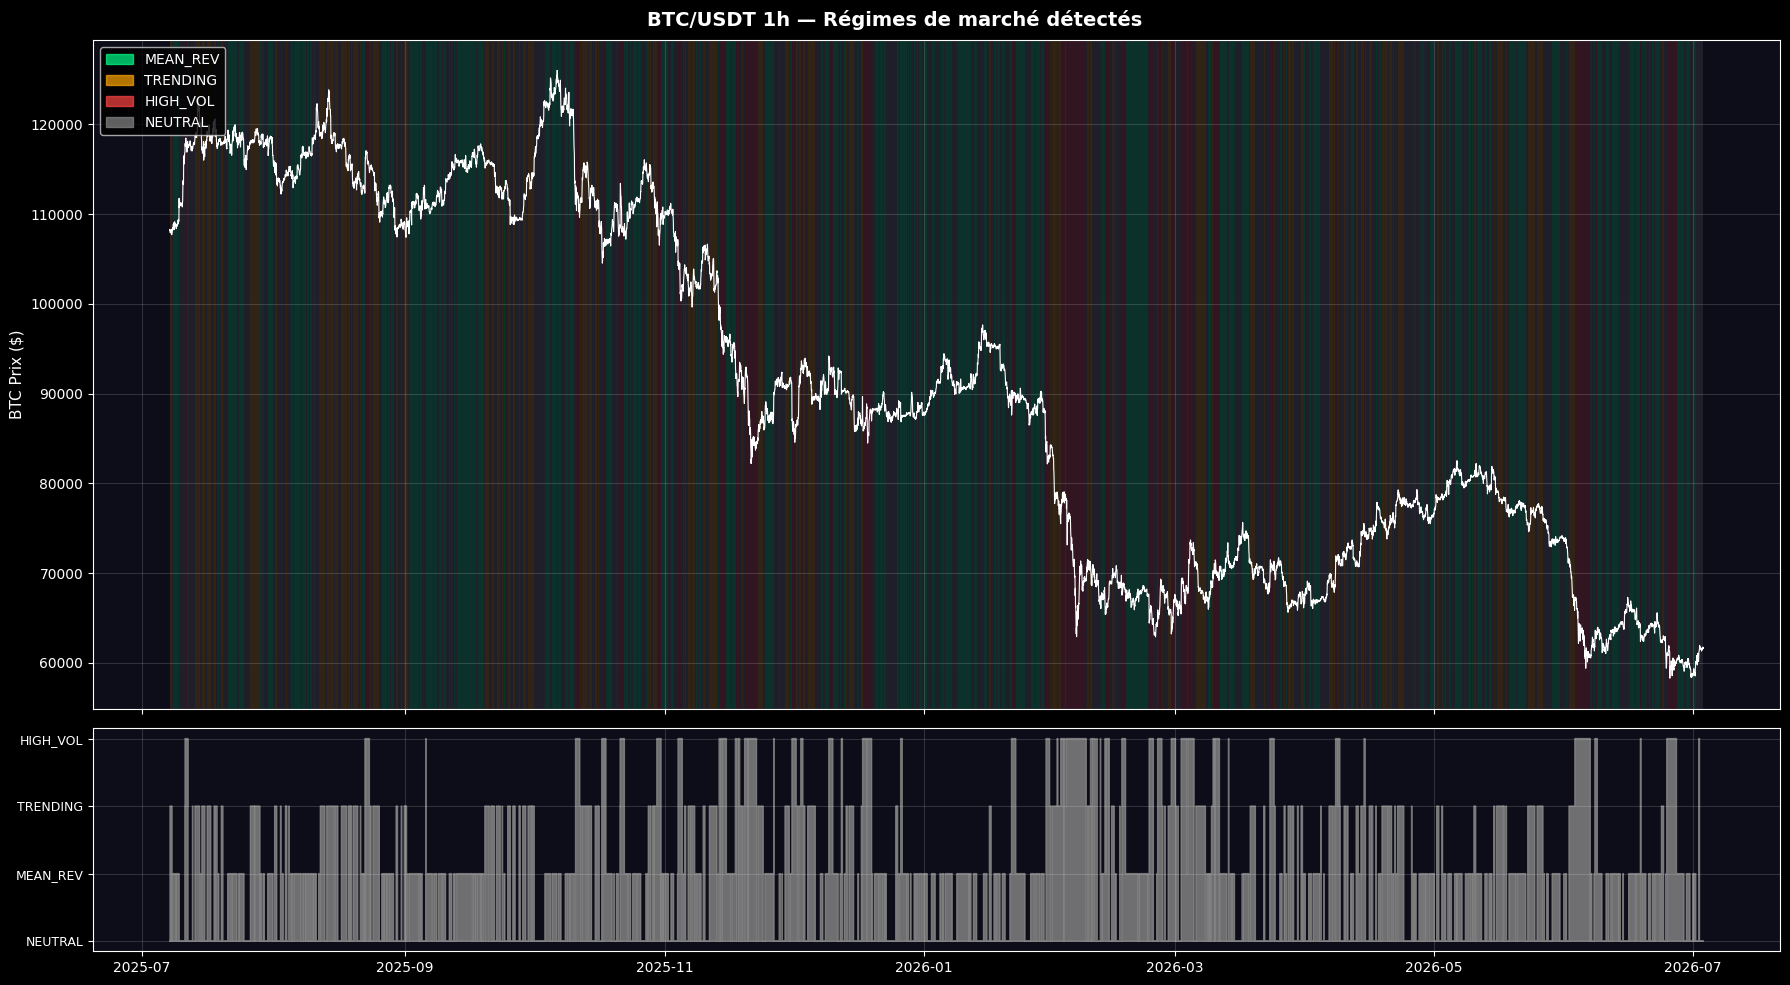

In [9]:
COLORS = {
    'MEAN_REV' : '#00ff88',
    'TRENDING' : '#ffa500',
    'HIGH_VOL' : '#ff4444',
    'NEUTRAL'  : '#888888',
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('BTC/USDT 1h — Régimes de marché détectés', fontsize=14, fontweight='bold')

# Graphique prix avec fond coloré par régime
ax1.plot(df.index, df['close'], color='white', linewidth=0.8, zorder=5)

# Colorer le fond selon le régime
prev_regime = None
start_idx   = df.index[0]

for i, (idx, row) in enumerate(df.iterrows()):
    regime = row['regime']
    if regime != prev_regime:
        if prev_regime is not None:
            ax1.axvspan(start_idx, idx, alpha=0.15,
                        color=COLORS[prev_regime], linewidth=0)
        start_idx  = idx
        prev_regime = regime

# Dernier segment
ax1.axvspan(start_idx, df.index[-1], alpha=0.15,
            color=COLORS[prev_regime], linewidth=0)

ax1.set_ylabel('BTC Prix ($)', fontsize=11)
ax1.set_facecolor('#0d0d1a')
ax1.grid(alpha=0.15)

# Légende
patches = [mpatches.Patch(color=c, label=r, alpha=0.7)
           for r, c in COLORS.items()]
ax1.legend(handles=patches, loc='upper left', fontsize=10)

# Bande régime en bas (timeline)
regime_num = df['regime'].map(
    {'MEAN_REV': 1, 'TRENDING': 2, 'HIGH_VOL': 3, 'NEUTRAL': 0}
)
ax2.fill_between(df.index, regime_num,
                 color=[COLORS[r] for r in df['regime']],
                 step='mid', alpha=0.8)
ax2.set_yticks([0, 1, 2, 3])
ax2.set_yticklabels(['NEUTRAL', 'MEAN_REV', 'TRENDING', 'HIGH_VOL'], fontsize=9)
ax2.set_facecolor('#0d0d1a')
ax2.grid(alpha=0.15)

plt.savefig('regime_chart.png', dpi=150, bbox_inches='tight', facecolor='#0a0d12')

plt.tight_layout()
plt.show()

## 6. Validation — Performance du Stat Arb par régime

In [10]:
# Est-ce que le régime MEAN_REV correspond vraiment à de meilleures conditions
# de mean-reversion ? On vérifie avec les rendements absolus sur 1h :
# → En MEAN_REV, les grands mouvements devraient se corriger rapidement
# → En TRENDING, les grands mouvements devraient continuer

df['abs_ret_1h']  = df['returns'].abs()
df['next_ret_1h'] = df['returns'].shift(-1)  # Rendement suivant
df['reversion']   = -(df['returns'] * df['next_ret_1h'])  # > 0 = reversion

print('📊 VALIDATION PAR RÉGIME')
print('='*65)
print(f'{"Régime":<12} | {"Reversion":<12} | {"Vol moy":<12} | {"ADX moy":<10} | {"Hurst moy"}')
print('-'*65)

for regime in ['MEAN_REV', 'NEUTRAL', 'TRENDING', 'HIGH_VOL']:
    sub = df[df['regime'] == regime]
    if len(sub) == 0: continue
    rev  = sub['reversion'].mean()
    vol  = sub['realized_vol'].mean()
    adx  = sub['adx'].mean()
    hurs = sub['hurst'].mean()
    sign = '✅' if (regime == 'MEAN_REV' and rev > 0) else \
           '✅' if (regime == 'TRENDING' and rev < 0) else \
           '✅' if (regime == 'HIGH_VOL' and vol > 1.0) else '⚠️'
    print(f'{sign} {regime:<10} | rev={rev:>+.5f}  | vol={vol:>6.3f}    | adx={adx:>6.1f}   | h={hurs:.3f}')

print('\n💡 Reversion > 0 = le marché a tendance à se corriger (bon pour stat arb)')
print('   Reversion < 0 = le marché a tendance à continuer (bon pour momentum)')

📊 VALIDATION PAR RÉGIME
Régime       | Reversion    | Vol moy      | ADX moy    | Hurst moy
-----------------------------------------------------------------
⚠️ MEAN_REV   | rev=-0.00000  | vol= 0.331    | adx=  25.9   | h=0.314
⚠️ NEUTRAL    | rev=-0.00000  | vol= 0.343    | adx=  37.3   | h=0.413
⚠️ TRENDING   | rev=+0.00000  | vol= 0.347    | adx=  44.4   | h=0.534
⚠️ HIGH_VOL   | rev=+0.00000  | vol= 0.768    | adx=  39.8   | h=0.411

💡 Reversion > 0 = le marché a tendance à se corriger (bon pour stat arb)
   Reversion < 0 = le marché a tendance à continuer (bon pour momentum)


## 7. Calibration des seuils — heatmap

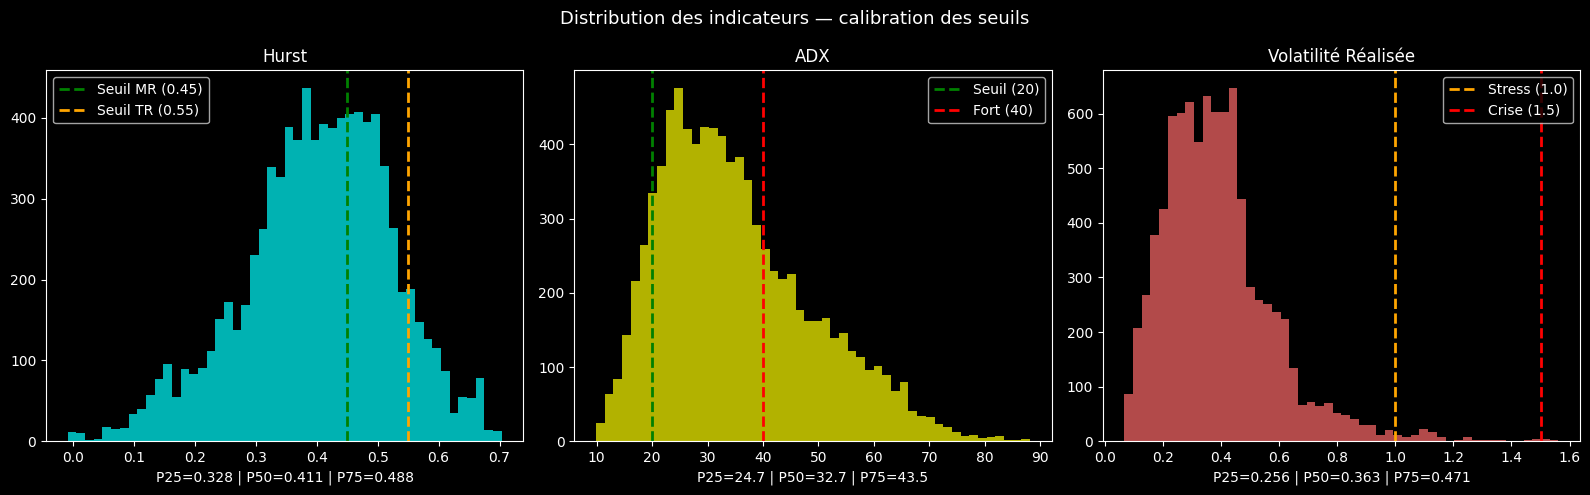


💡 Ces distributions te permettent de calibrer les seuils.
   Idéalement MEAN_REV = ~25-30% du temps, TRENDING = ~30%, HIGH_VOL = ~15%, NEUTRAL = reste


In [11]:
# Distribution des indicateurs — aide à choisir les bons seuils
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution des indicateurs — calibration des seuils', fontsize=13)

# Hurst
axes[0].hist(df['hurst'], bins=50, color='cyan', alpha=0.7, edgecolor='none')
axes[0].axvline(0.45, color='green',  linestyle='--', linewidth=2, label='Seuil MR (0.45)')
axes[0].axvline(0.55, color='orange', linestyle='--', linewidth=2, label='Seuil TR (0.55)')
axes[0].set_title('Hurst')
axes[0].legend()
axes[0].set_xlabel('Valeur')
p25, p50, p75 = df['hurst'].quantile([0.25, 0.5, 0.75])
axes[0].set_xlabel(f'P25={p25:.3f} | P50={p50:.3f} | P75={p75:.3f}')

# ADX
axes[1].hist(df['adx'], bins=50, color='yellow', alpha=0.7, edgecolor='none')
axes[1].axvline(20, color='green', linestyle='--', linewidth=2, label='Seuil (20)')
axes[1].axvline(40, color='red',   linestyle='--', linewidth=2, label='Fort (40)')
axes[1].set_title('ADX')
axes[1].legend()
p25, p50, p75 = df['adx'].quantile([0.25, 0.5, 0.75])
axes[1].set_xlabel(f'P25={p25:.1f} | P50={p50:.1f} | P75={p75:.1f}')

# Volatilité
axes[2].hist(df['realized_vol'], bins=50, color='#ff6b6b', alpha=0.7, edgecolor='none')
axes[2].axvline(1.0, color='orange', linestyle='--', linewidth=2, label='Stress (1.0)')
axes[2].axvline(1.5, color='red',    linestyle='--', linewidth=2, label='Crise (1.5)')
axes[2].set_title('Volatilité Réalisée')
axes[2].legend()
p25, p50, p75 = df['realized_vol'].quantile([0.25, 0.5, 0.75])
axes[2].set_xlabel(f'P25={p25:.3f} | P50={p50:.3f} | P75={p75:.3f}')

plt.tight_layout()
plt.show()

print('\n💡 Ces distributions te permettent de calibrer les seuils.')
print('   Idéalement MEAN_REV = ~25-30% du temps, TRENDING = ~30%, HIGH_VOL = ~15%, NEUTRAL = reste')

## 8. Sauvegarde

In [12]:
# ── WALK-FORWARD VALIDATION ───────────────────────────────────
# On découpe l'année en 3 périodes de 4 mois
# et on vérifie que la séparation Hurst/ADX reste cohérente
# → Un bon classifieur doit fonctionner sur tous les régimes de marché

print('📊 WALK-FORWARD VALIDATION — 3 périodes de 4 mois')
print('='*70)

n = len(df)
periods = {
    'Période 1 (mois 1-4)' : df.iloc[:n//3],
    'Période 2 (mois 5-8)' : df.iloc[n//3:2*n//3],
    'Période 3 (mois 9-12)': df.iloc[2*n//3:],
}

for name, sub in periods.items():
    dist = sub['regime'].value_counts(normalize=True) * 100
    btc_ret = (sub['close'].iloc[-1] / sub['close'].iloc[0] - 1) * 100
    hurst_mr  = sub[sub['regime']=='MEAN_REV']['hurst'].mean()
    hurst_tr  = sub[sub['regime']=='TRENDING']['hurst'].mean()
    sep_ok = '✅' if (not pd.isna(hurst_mr) and not pd.isna(hurst_tr) 
                      and hurst_tr > hurst_mr + 0.05) else '⚠️'
    
    print(f'\n{sep_ok} {name} | BTC: {btc_ret:+.1f}%')
    print(f'   Distribution : ', end='')
    for regime in ['MEAN_REV','TRENDING','HIGH_VOL','NEUTRAL']:
        pct = dist.get(regime, 0)
        print(f'{regime}={pct:.0f}%  ', end='')
    print()
    if not pd.isna(hurst_mr) and not pd.isna(hurst_tr):
        print(f'   Hurst MEAN_REV={hurst_mr:.3f} vs TRENDING={hurst_tr:.3f} '
              f'(écart={hurst_tr-hurst_mr:.3f})')

print('\n💡 ✅ = bonne séparation Hurst entre MEAN_REV et TRENDING (écart > 0.05)')
print('   ⚠️ = séparation faible sur cette période → classifieur moins fiable')

# ── STABILITÉ DES SEUILS ──────────────────────────────────────
print('\n📊 STABILITÉ DES INDICATEURS PAR PÉRIODE')
print('='*70)
print(f'{"":<25} | {"Hurst P50":<12} | {"ADX P50":<12} | {"Vol P85":<12}')
print('-'*70)
for name, sub in periods.items():
    h50  = sub['hurst'].quantile(0.5)
    a50  = sub['adx'].quantile(0.5)
    v85  = sub['realized_vol'].quantile(0.85)
    print(f'{name:<25} | {h50:<12.3f} | {a50:<12.1f} | {v85:<12.3f}')

print('\n💡 Si les percentiles varient beaucoup entre périodes → seuils fixes risqués')
print('   Solution future : seuils adaptatifs (percentiles glissants)')

📊 WALK-FORWARD VALIDATION — 3 périodes de 4 mois

✅ Période 1 (mois 1-4) | BTC: -6.9%
   Distribution : MEAN_REV=34%  TRENDING=22%  HIGH_VOL=5%  NEUTRAL=39%  
   Hurst MEAN_REV=0.326 vs TRENDING=0.533 (écart=0.207)

✅ Période 2 (mois 5-8) | BTC: -27.7%
   Distribution : MEAN_REV=31%  TRENDING=14%  HIGH_VOL=21%  NEUTRAL=33%  
   Hurst MEAN_REV=0.300 vs TRENDING=0.533 (écart=0.234)

✅ Période 3 (mois 9-12) | BTC: -15.3%
   Distribution : MEAN_REV=33%  TRENDING=18%  HIGH_VOL=9%  NEUTRAL=40%  
   Hurst MEAN_REV=0.315 vs TRENDING=0.536 (écart=0.220)

💡 ✅ = bonne séparation Hurst entre MEAN_REV et TRENDING (écart > 0.05)
   ⚠️ = séparation faible sur cette période → classifieur moins fiable

📊 STABILITÉ DES INDICATEURS PAR PÉRIODE
                          | Hurst P50    | ADX P50      | Vol P85     
----------------------------------------------------------------------
Période 1 (mois 1-4)      | 0.424        | 32.7         | 0.455       
Période 2 (mois 5-8)      | 0.399        | 32.4     

In [13]:
df[['close','hurst','adx','realized_vol','regime']].to_csv('../data/regime_history.csv')
print(f'💾 regime_history.csv sauvegardé — {len(df)} lignes')
print(f'\n🎯 PROCHAINE ÉTAPE :')
print(f'   → compute_regime.py : script live qui calcule le régime actuel')
print(f'   → live_regime.py    : boucle toutes les heures, écrit le régime dans un fichier')
print(f'   → live_bot.py       : lire le régime avant chaque entrée en position')

💾 regime_history.csv sauvegardé — 8661 lignes

🎯 PROCHAINE ÉTAPE :
   → compute_regime.py : script live qui calcule le régime actuel
   → live_regime.py    : boucle toutes les heures, écrit le régime dans un fichier
   → live_bot.py       : lire le régime avant chaque entrée en position
